# Used Bike Price Prediction
## Business Problem:-
The objective of this project is to analyze used bike data and build a machine learning model to predict bike prices based on various features such as brand, mileage, power, engine capacity, ownership history, and location.


In [131]:
# Basic Libraries:-
import numpy as np
import pandas as pd

# Visualization:-
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings:-
import warnings
warnings.filterwarnings("ignore")

In [132]:
df = pd.read_csv("bikes.csv")
df.head()

,model_name,model_year,kms_driven,owner,location,mileage,power,price
0,Bajaj Avenger Cruise 220 2017,2017,17000 Km,first owner,hyderabad,\n\n 35 kmpl,19 bhp,63500
1,Royal Enfield Classic 350cc 2016,2016,50000 Km,first owner,hyderabad,\n\n 35 kmpl,19.80 bhp,115000
2,Hyosung GT250R 2012,2012,14795 Km,first owner,hyderabad,\n\n 30 kmpl,28 bhp,300000
3,Bajaj Dominar 400 ABS 2017,2017,Mileage 28 Kms,first owner,pondicherry,\n\n 28 Kms,34.50 bhp,100000
4,Jawa Perak 330cc 2020,2020,2000 Km,first owner,bangalore,\n\n,30 bhp,197500


In [133]:
df.shape

(7857, 8)

In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7857 entries, 0 to 7856
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   model_name  7857 non-null   object
 1   model_year  7857 non-null   int64 
 2   kms_driven  7857 non-null   object
 3   owner       7857 non-null   object
 4   location    7838 non-null   object
 5   mileage     7846 non-null   object
 6   power       7826 non-null   object
 7   price       7857 non-null   int64 
dtypes: int64(2), object(6)
memory usage: 491.2+ KB


In [135]:
df.describe()

,model_year,price
count,7857.000000,7.857000e+03
mean,2015.367698,1.067913e+05
std,4.001443,1.389261e+05
min,1950.000000,0.000000e+00
25%,2014.000000,4.200000e+04
50%,2016.000000,7.500000e+04
75%,2018.000000,1.250000e+05
max,2021.000000,3.000000e+06


In [136]:
df.isnull().sum()

model_name     0
model_year     0
kms_driven     0
owner          0
location      19
mileage       11
power         31
price          0
dtype: int64

In [137]:
df.sample(10)

,model_name,model_year,kms_driven,owner,location,mileage,power,price
5302,KTM Duke 390cc 2014,2014,53000 Km,first owner,mumbai,\n\n 25 kmpl,44 bhp,100000
6209,TVS Apache 150cc 2012,2012,Mileage 45 Kmpl,first owner,bangalore,\n\n 45 Kmpl,13.7 Bhp,35000
7123,Royal Enfield Thunderbird 350cc 2010,2010,50000 Km,first owner,bangalore,\n\n 35 kmpl,19.80 bhp,62700
2765,Bajaj V15 150cc 2017,2017,4200 Km,first owner,kolkata,\n\n 57 kmpl,11.80 bhp,49000
1505,Royal Enfield Classic Gunmetal Grey 350cc 2019,2019,9000 Km,first owner,chandigarh,\n\n 35 kmpl,19.80 bhp,180000
7176,Harley-Davidson Street 750 ABS 2018,2018,1174 Km,second owner,delhi,\n\n 20 kmpl,47 bhp,450000
5048,Royal Enfield Thunderbird 500cc 2018,2018,6355 Km,first owner,ghaziabad,\n\n 25 kmpl,27.20 bhp,185000
4193,TVS Apache RTR 200 4V ABS Race Edition 2018,2018,Mileage 40 Kmpl,first owner,delhi,\n\n 40 Kmpl,20.23 BHP,70000
5725,Harley-Davidson Street 750 2014,2014,1100 Km,first owner,dehradun,\n\n 20 kmpl,47 bhp,390000
6957,Bajaj Discover 100M 2012,2012,Mileage 80 Kmpl,second owner,lucknow,\n\n 80 Kmpl,9.10 bhp,31080


# ata Cleaning:-
## Cleaning kms_driven:-
Problem:
- Contains "Km"
- Contains "Mileage 40 Kmpl"
- Contains text
We need only numeric kilometers.

In [138]:
# Extract only digits from kms_driven:-
df['kms_driven'] = df['kms_driven'].str.extract('(\d+)')

# Convert to numeric:-
df['kms_driven'] = pd.to_numeric(df['kms_driven'], errors='coerce')

# Check nulls:-
df['kms_driven'].isnull().sum()

3

Why the you use errors = 'coerce'?
- Because some entries contained invalid text values. Using coerce converts them into NaN so they can be handled properly.

In [139]:
df['kms_driven'].describe()

count       7854.000000
mean       17267.701935
std        26761.689455
min            0.000000
25%          104.000000
50%        11000.000000
75%        25000.000000
max      1000000.000000
Name: kms_driven, dtype: float64

In [140]:
median_kms = df['kms_driven'].median()
df['kms_driven'].fillna(median_kms, inplace=True)
df['kms_driven'].isnull().sum()

0

Why the use of median instead of mean?
- Kilometers driven typically contains outliers. Median is less sensitive to extreme values and therefore gives a more stable central tendency.

## Cleaning mileage column:-
Problem:
- "\n\n 35 kmpl"
- "40 Kmpl"
- Some missing values
Solution:
- Extract numeric values using regex.

In [141]:
df['mileage'] = df['mileage'].astype(str).str.extract('(\d+\.?\d*)')

df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')

df['mileage'].isnull().sum()

774

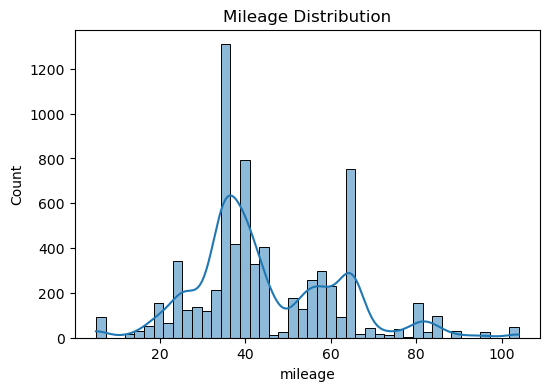

In [142]:
df['mileage'].describe()

plt.figure(figsize=(6,4))
sns.histplot(df['mileage'], kde=True)
plt.title('Mileage Distribution')
plt.show()

- The distribution is clearly not normal.
- It appears right-skewed.
There seem to be multiple peaks:
- Around 35–40 kmpl
- Around 60–65 kmpl
There are extreme values near 90–100 kmpl (possible outliers).
This tells us something very important:
- Different bike segments behave differently.
- Performance bikes → low mileage
- Commuter bikes → high mileage
So filling missing mileage with overall median would ignore brand differences.
That’s why we will use brand-wise median imputation.

In [143]:
# Extracting the brand:-
df['brand'] = df['model_name'].str.split().str[0]
df['brand'].unique()

array(['Bajaj', 'Royal', 'Hyosung', 'Jawa', 'KTM', 'TVS', 'Yamaha',
       'Honda', 'UM', 'Hero', 'Suzuki', 'Husqvarna', 'Mahindra',
       'Harley-Davidson', 'Kawasaki', 'Benelli', 'Triumph', 'Ducati',
       'BMW', 'Ideal', 'BenelliImperiale', 'Moto', 'Fb', 'Indian',
       'Yazdi', 'Aprilia', 'MV', 'yamaha'], dtype=object)

In [144]:
# Fix lowercase yamaha:-
df['brand'] = df['brand'].replace('yamaha', 'Yamaha')

# Fix Royal --> Royal Enfield:-
df.loc[df['model_name'].str.contains('Royal Enfield', case=False), 'brand'] = 'Royal Enfield'

# Fix BenelliImperiale:-
df.loc[df['brand'] == 'BenelliImperiable', 'brand'] = 'Benelli'

# Fix Ideal --> Jawa:-
df.loc[df['brand'] == 'Ideal', 'brand'] = 'Jawa'


In [145]:
df.loc[df['brand'] == 'Ideal', 'brand'] = 'Jawa'
df.loc[df['brand'].str.contains('BenelliImperiale', na=False), 'brand'] = 'Benelli'
df.loc[df['brand'] == 'Fb', 'brand'] = 'Unknown'
df.loc[df['brand'] == 'Moto', 'brand'] = 'Moto Guzzi'

In [146]:
df['brand'].unique()

array(['Bajaj', 'Royal Enfield', 'Hyosung', 'Jawa', 'KTM', 'TVS',
       'Yamaha', 'Honda', 'UM', 'Hero', 'Suzuki', 'Husqvarna', 'Mahindra',
       'Harley-Davidson', 'Kawasaki', 'Benelli', 'Triumph', 'Ducati',
       'BMW', 'Moto Guzzi', 'Unknown', 'Indian', 'Yazdi', 'Aprilia', 'MV'],
      dtype=object)

Why did we manually adjust brands?
- Brand names extracted from model_name contained inconsistencies due to formatting issues. Since brand is an important categorical predictor, I normalized them to avoid splitting same brands into multiple categories.

Brand Wise median :-
- Now, brand is clean, we will fill missing values using:
"brand-wise median"

In [147]:
df['mileage'] = df.groupby('brand')['mileage'].transform(
    lambda x: x.fillna(x.median())
)
df['mileage'].isnull().sum()

60

In [148]:
# Filling remaining nulls with overall median:-
df['mileage'].fillna(df['mileage'].median(), inplace=True)

df['mileage'].isnull().sum()

0

How did I handle the missing Mileage Values?
- I first applied brand-wise median imputation to preserve segment-specific mileage characteristics. For brands where all values were missing, I used global median as a fallback strategy.

## Cleaning Power Column:-
Problem:-
- "19 bhp"
- "20.23 BHP"
- "8.51 PS"
- "15 hp"
- "19 bhp @ 5250 rpm"

Solution:-
1. Remove text like bhp, BHP, @ rpm
2. Convert PS and hp to bhp
3. Convert to numeric
4. Handle missing values

In [149]:
df['power'].describe()

count          7826
unique          272
top       19.80 bhp
freq            922
Name: power, dtype: object

Type of column is Object first we need to convert it into float 

In [150]:
# Convert to string and lowercase:-
df['power'] = df['power'].astype(str).str.lower()

# Remove text after '@':-
df['power'] = df['power'].str.split('@').str[0]

# Extract numeric part:-
df['power'] = df['power'].str.extract('(\d+\.?\d*)')

# Convert to numeric:-
df['power'] = pd.to_numeric(df['power'], errors='coerce')

# Check null count:-
df['power'].isnull().sum()

31

In [151]:
df['power'].describe()

count    7826.000000
mean       20.765127
std        15.016736
min         6.100000
25%        14.000000
50%        19.000000
75%        24.160000
max       197.300000
Name: power, dtype: float64

In [152]:
# Removing null values:-
df['power'] = df.groupby('brand')['power'].transform(
    lambda x: x.fillna(x.median())
)
df['power'].fillna(df['power'].median(), inplace=True)

In [153]:
df['power'].isnull().sum()

0

Now, Cleaned Columns so far:-
- kms_driven → numeric, no nulls
- mileage → numeric, no nulls
- power → numeric, no nulls
- price → numeric
- brand → cleaned categorical
- model_year → numeric

# Feature Engineering:-
Now, we extract Engine CC from model_name
This is important because:-
- Engine capacity strongly affects price
- Power and CC together explain performance segment

In [154]:
# Extracting Engine CC from model_name:-
df['cc_temp'] = df['model_name'].str.extract('(\d{2,4})')

df['cc_temp'] = pd.to_numeric(df['cc_temp'], errors='coerce')

df['cc_temp'].isnull().sum()

0

But above logic will extract model year also so, we have to remove them logically like:-
- Engine cc is uasually between 50 to 2000
- Almost never above 2000
- Model years are typically 1950-2021
- So remove values >= 1950

In [155]:
df['cc_temp'] = df['cc_temp'].apply(
    lambda x: np.nan if x >= 1950 else x
)
df['cc_temp'].isnull().sum()

250

Now, 250 null values in cc_temp. These are cases where the first 2–4 digit number was actually the year. And the model name did not contain another clear CC number

Some model names look like:
- "Bajaj Pulsar 2017"
- "TVS Apache RTR 2018"
- "Hero Passion Pro 2016"

In these cases, there is no engine capacity explicitly written.

##### Intelligent CC Imputation
Since engine capacity strongly related to brand, we will:
- step 1 :- Fill using brand-wise median
- step 2 :- Global median fallback

Brand-Wise because:
- Hero bikes usually ~100-150cc
- Royal Enfield ~350-650cc
- Ducati ~800+ cc
- KTM ~200-390cc
- If we fill everything with overall  median, it would destroy brand identity.

In [156]:
# df['cc'] = df.groupby('brand')['cc'].transform(
#     lambda x: x.fillna(x.median())
# )
# df['cc'].isnull().sum()

import re

def extract_cc(row):
    numbers = re.findall(r'\d{2,4}', row['model_name'])
    
    for num in numbers:
        num = int(num)
        
        if num == row['model_year']:
            continue
        
        if num >= 1950:
            continue
        
        return num
    
    return np.nan

df['cc'] = df.apply(extract_cc, axis=1)

df['cc'].isnull().sum()


250

In [157]:
df['cc'].fillna(df['cc'].median(), inplace=True)
df['cc'].isnull().sum()

0

##### How did I handle missing engine capacity values?
I first extracted engine capacity from model names using regex and filtered out model years. Missing values were imputed using brand-wise median to preserve brand characteristics, followed by global median as a fallback."

## Create Bike Age Feature:-
Because:
- Price depends more on age than raw model year.

Example:
- 2018 bike in 2023 → 5 years old
- 2018 bike in 2021 → 3 years old

Age captures depreciation effect better.

In [158]:
current_year = 2026
df['bike_age'] = current_year - df['model_year']
df[['model_year', 'bike_age']].head()

,model_year,bike_age
0,2017,9
1,2016,10
2,2012,14
3,2017,9
4,2020,6


In [159]:
df['bike_age'].describe()

count    7857.000000
mean       10.632302
std         4.001443
min         5.000000
25%         8.000000
50%        10.000000
75%        12.000000
max        76.000000
Name: bike_age, dtype: float64

Some very old Bikes(76 years old -> model year 1950)
That's an extreme outlier

In [160]:
df[df['bike_age']>40].shape

(12, 12)

There are 12 rows where bike_age > 40. We can remove them properly, because they are extreme outliers.

In [161]:
df = df[df['bike_age'] <= 40]
df.shape

(7845, 12)

# Exploratory Data Analysis (EDA):-

#### Price vs Bike Age:-

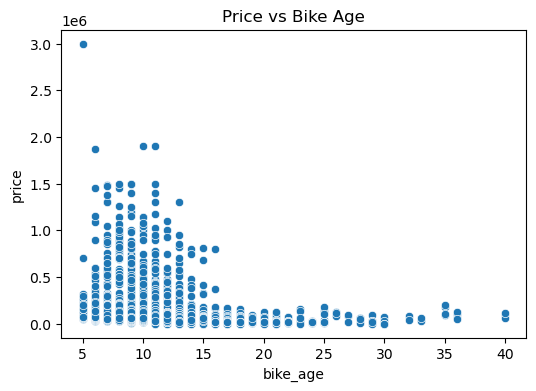

In [162]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['bike_age'], y=df['price'])
plt.title('Price vs Bike Age')
plt.show()

#### Price vs KMS Driven:-

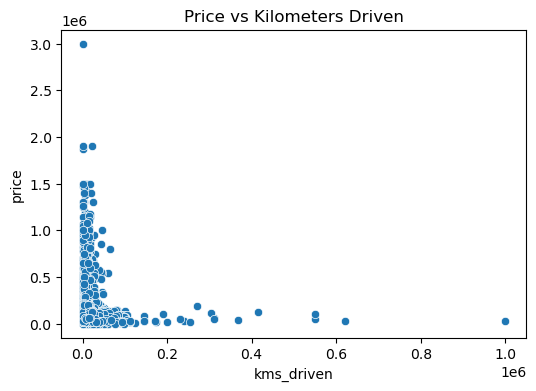

In [163]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['kms_driven'], y=df['price'])
plt.title('Price vs Kilometers Driven')
plt.show()

#### Correlation Heatmap:-

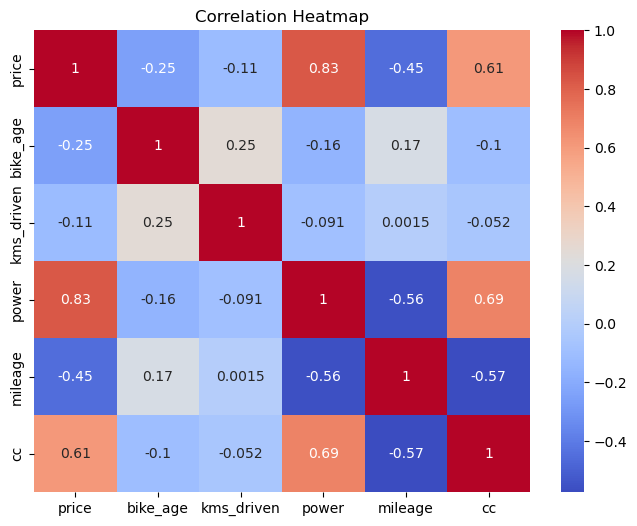

In [164]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['price', 'bike_age', 'kms_driven', 'power', 'mileage', 'cc']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

##### What factors influence used bike price the most?
The strongest predictor is engine power (correlation 0.83), followed by engine capacity (0.61). Mileage and bike age negatively impact price, reflecting depreciation and performance segment differences.

# Modelling stage:-

In [165]:
df_model = df.drop(['model_name', 'model_year', 'cc_temp'], axis=1)
df_model.head()

,kms_driven,owner,location,mileage,power,price,brand,cc,bike_age
0,17000.0,first owner,hyderabad,35.0,19.0,63500,Bajaj,220.0,9
1,50000.0,first owner,hyderabad,35.0,19.8,115000,Royal Enfield,350.0,10
2,14795.0,first owner,hyderabad,30.0,28.0,300000,Hyosung,250.0,14
3,28.0,first owner,pondicherry,28.0,34.5,100000,Bajaj,400.0,9
4,2000.0,first owner,bangalore,40.0,30.0,197500,Jawa,330.0,6


In [177]:
df_model['location'].fillna(df['location'].mode()[0], inplace=True)
df_model = df_model.drop('location', axis=1)

Dropping the location column because due to pd.get_dummies hundreds of dummy columns for location has created which is creating problem.

In [180]:
# Defining features and Target:-
x = df_model.drop('price', axis=1)
y = df_model['price']
x.shape, y.shape

((7845, 7), (7845,))

In [181]:
# Encode Categorical Variables:-
x = pd.get_dummies(x, drop_first=True)
x.shape

(7845, 32)

#### Why drop_first=True?
Dummy variable trap (multicollinearity in linear regression)

High-cardinality categorical features can destroy linear regression if naively one-hot encoded.

In [198]:
# Train-Test Split:-
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
x_train.shape, x_test.shape

((6276, 32), (1569, 32))

In [199]:
# Training Linear Regression:-
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)

y_pred = lr.predict(x_test)

In [200]:
# Evaluate Model:-
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('MAE:', mae)
print('MSE:', mse)
print('R2 SCORE:', r2)

MAE: 29257.51609517829
MSE: 8700977031.821266
R2 SCORE: 0.6675718762169642


R² = 0.67

That means:
- The model explains 67% of variance in bike prices.
- For a simple Linear Regression model, this is decent.

- Linear regression captures general trend.
- There is still non-linearity in data.
- Tree-based models will likely perform better.

Solution:-
- We still have multicollinearity (power & cc correlated 0.69)
- Ridge helps stabilize coefficients.

In [201]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(x_train, y_train)

y_pred_ridge = ridge.predict(x_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge MAE:", mae_ridge)
print("Ridge RMSE:", rmse_ridge)
print("Ridge R2:", r2_ridge)

Ridge MAE: 29665.89164315232
Ridge RMSE: 93396.44868472265
Ridge R2: 0.6667344197054192


In [202]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)

Random Forest MAE: 19419.049999668194
Random Forest RMSE: 85249.5410215425
Random Forest R2: 0.7223396702292478


Random Forest improved performance
R² improved from 0.67 → 0.72
MAE reduced significantly from 29k → 19k
But It’s Not 0.85+
That means:
- Data still has noise
- Location was removed (may contain useful signal)
- Some nonlinear patterns still not captured
- Hyperparameters not tuned yet

# Feature Importance:-

In [203]:
import pandas as pd
feature_importances = pd.Series(
    rf.feature_importances_,
    index=x.columns).sort_values(ascending=False)
feature_importances.head(10)

power                    0.725322
cc                       0.112417
bike_age                 0.061126
kms_driven               0.060335
mileage                  0.017298
brand_Royal Enfield      0.003877
brand_Indian             0.003844
brand_Harley-Davidson    0.001987
brand_Hyosung            0.001783
owner_second owner       0.001740
dtype: float64

#### What factors influence used bike price the most?
Feature importance from Random Forest shows engine power contributes over 72% to price prediction. Engine capacity, bike age, and kilometers driven also influence price, while brand and owner history have relatively minor impact.

## Final Model Selection

After comparing Linear Regression, Ridge Regression, and Random Forest Regressor:

- Random Forest performed best with R² ≈ 0.72
- MAE reduced significantly compared to linear models
- Non-linear relationships exist between engine specifications and price

Therefore, Random Forest was selected as the final model.


# Important Graphs/plots:-
#### 1.Correlation Heatmap (EDA Section):-

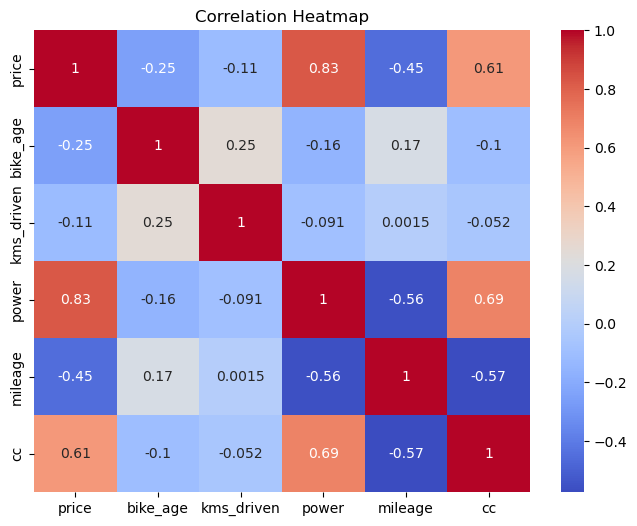

In [207]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[['price','bike_age','kms_driven','power','mileage','cc']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

#### 2.Price vs Bike Age (Depreciation Effect):-

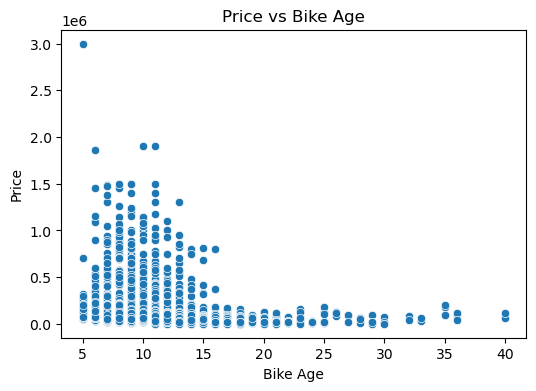

In [216]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['bike_age'], y=df['price'])
plt.title("Price vs Bike Age")
plt.xlabel("Bike Age")
plt.ylabel("Price")
plt.show()

#### 3. Actual vs Predicted (Model Evaluation Section):-

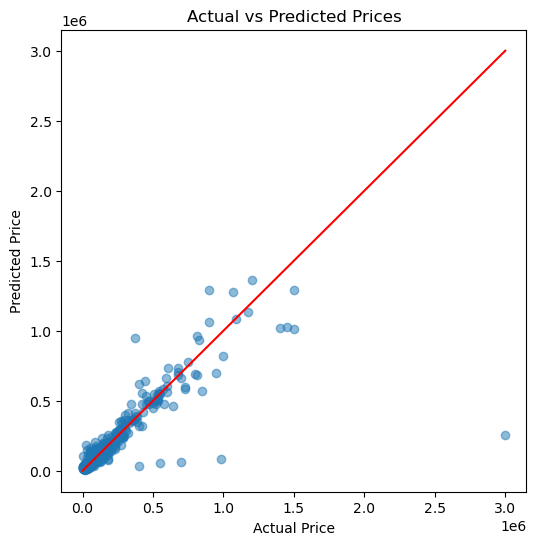

In [218]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)
plt.show()


#### 4. Feature Importance:-

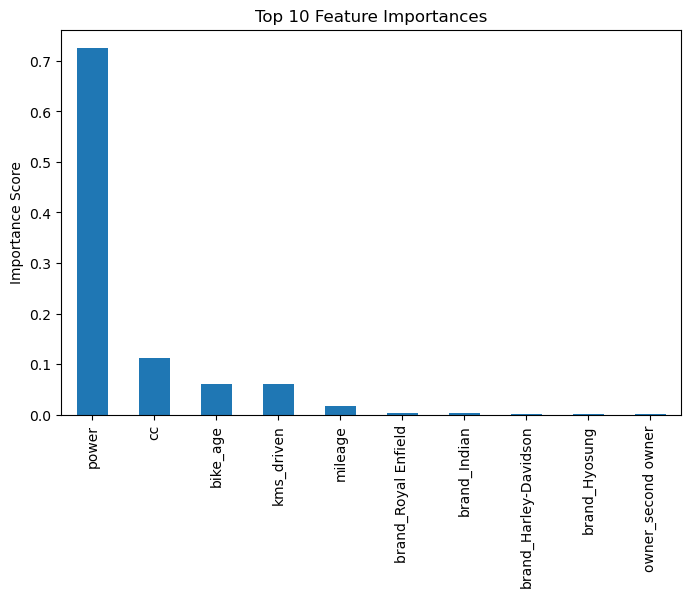

In [220]:
feature_importances = pd.Series(
    rf.feature_importances_,
    index=x_train.columns
).sort_values(ascending=False)

top_features = feature_importances.head(10)

plt.figure(figsize=(8,5))
top_features.plot(kind='bar')
plt.title("Top 10 Feature Importances")
plt.ylabel("Importance Score")
plt.show()

## Key Business Insights

1. Engine power is the strongest driver of used bike price.
2. Engine capacity also significantly impacts valuation.
3. Depreciation effects are visible through bike age and kilometers driven.
4. Brand influence is weaker compared to performance specifications.
5. Mileage has minimal effect on resale value in this dataset.


## Future Improvements

- Hyperparameter tuning of Random Forest
- Try Gradient Boosting / XGBoost
- Handle high-cardinality location feature using target encoding
- Perform cross-validation
- Detect and treat price outliers
